<a href="https://colab.research.google.com/github/shabanovanp-ship-it/my-colab-project-TATA/blob/main/%D0%A2%D0%90%D0%A2%D0%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Анализ продаж британского e-commerce магазина ТАТА (поиск инсайтов и составление рекомендаций стейкхолдерам)**

**Блок 1. Описание датасета и типа данных**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import  pandas as pd
import seaborn as sns
from functools import reduce

In [ ]:
data = pd.read_csv('/content/Online Retail Data Set.csv', encoding = 'unicode_escape')
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
data.shape

(541909, 8)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Имя столбца - Описание:
1.   InvoiceNo -	Номер счет-фактуры
2.   StockCode	- Артикул товара
3.   Description	- Описание товара
4.   Quantity -	Количество товара
5.   InvoiceDate	- Дата покупки
6.   UnitPrice -	Цена за единицу товара
7.   CustomerID	- ID пользователя
8.   Country -	Страна

**Блок 2. Очистка и подготовка данных**

Проверяем на наличие дубликатов

In [ ]:
data.duplicated().sum()

5268


Обнаружили 5268 дубликатов

In [ ]:
# удаляем дубликаты
data = data.drop_duplicates()
data.duplicated().sum()

0

Проверяем на наличие пропущенных значений

In [ ]:
(data.isna().mean()*100).round(2) # % пропусков в каждом столбце

InvoiceNo       0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
UnitPrice       0.00
CustomerID     25.16
Country         0.00
dtype: float64

В столбце 'Description' и 'CustomerID' есть пропущенные значения

Обработка пропущенных значений

In [ ]:
# Заполняем пропущенные значения в наших данных
data['Description'] = data['Description'].fillna("Unknown")
data['CustomerID'] = data['CustomerID'].fillna(0)

In [ ]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

Теперь мы можем двигаться дальше, поскольку больше нет пустых значений


Измение формата данных 'Invoice', 'Quantity', 'UnitPrice'

In [ ]:
# переведем формат столбца 'InvoiceDate' в формат datetime
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'], format = '%d-%m-%Y %H:%M')
data['Quantity'] = pd.to_numeric(data['Quantity'])
data['UnitPrice'] = pd.to_numeric(data['UnitPrice'])

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    536641 non-null  object        
 1   StockCode    536641 non-null  object        
 2   Description  536641 non-null  object        
 3   Quantity     536641 non-null  int64         
 4   InvoiceDate  536641 non-null  datetime64[ns]
 5   UnitPrice    536641 non-null  float64       
 6   CustomerID   536641 non-null  float64       
 7   Country      536641 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 36.8+ MB


In [ ]:
#создаем отдельный столбец для времени time
data['Time'] = data['InvoiceDate'].dt.time
#создаём отдельный столбец для дня недели day
data['Day'] = data['InvoiceDate'].dt.day_name()
# создаём отдельный столбец для года-месяца
data['Year_month'] = data['InvoiceDate'].dt.to_period('M')

In [ ]:
#создаём новый столбец 'Total' - общая выручка за позицию в чеке
data['Total'] = data['Quantity']*data['UnitPrice']

In [ ]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34


<Axes: ylabel='UnitPrice'>

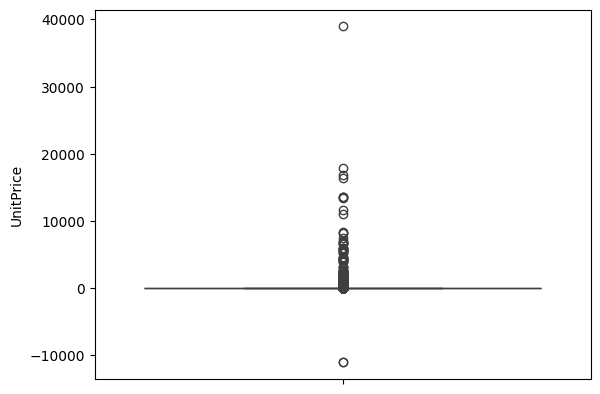

In [ ]:
#Проверяем рапспределение величины 'UnitPrice'
sns.boxplot(y = 'UnitPrice', data=data)

На графике видно, что есть отрицательные значений

In [ ]:
data[data['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,0.0,United Kingdom,14:51:00,Friday,2011-08,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,0.0,United Kingdom,14:52:00,Friday,2011-08,-11062.06


Эти данные помечены как корректировка проблемных возвратов.
Есть несколько счетов-фактур, которые в столбце 'Description' помечены как долг. Найдём строки, содержащие слово 'DEBT' или 'debt'

In [ ]:
data[data['Description'].str.contains('debt', case=False)] # поиск нерегистрозависимый

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
299982,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,0.0,United Kingdom,14:50:00,Friday,2011-08,11062.06
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,0.0,United Kingdom,14:51:00,Friday,2011-08,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,0.0,United Kingdom,14:52:00,Friday,2011-08,-11062.06


In [ ]:
mask = data['Description'].str.contains('debt', case=False)
# Оставим только те строки, которые не содержат 'debt'
data = data[~mask]

In [ ]:
data = data[data['UnitPrice']>0] # оставили только те строчки, где цена больше 0

In [ ]:
#Теперь проверим минимальную цену
data['UnitPrice'].min()

0.001

In [ ]:
#проверили максимальную цену
data['UnitPrice'].max()

38970.0

In [ ]:
# посмотрим, что за товар имеет максимальную цену?
data[data['UnitPrice'] == 38970.0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,38970.0,15098.0,United Kingdom,15:31:00,Friday,2011-06,-38970.0


Максимальная цена за товар выглядит странно, в описании помечена как "инструкция", возможно ручная корректировка недостачи.


<Axes: ylabel='Quantity'>

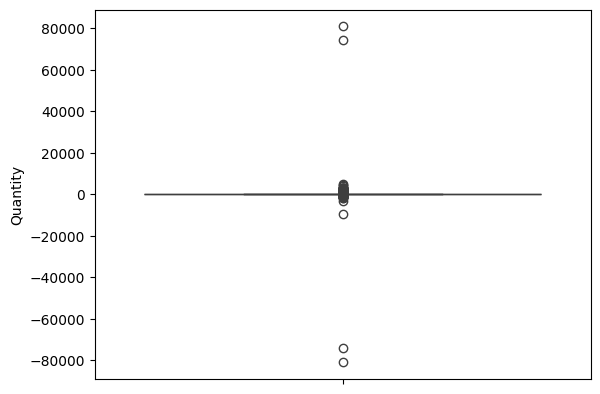

In [ ]:
sns.boxplot(y = 'Quantity', data=data)

 На графике видно, что в столбце 'Quantity' есть отрицательные значения, что вероятно происходит при отмене покупки

In [ ]:
data[data['Quantity']<0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,09:41:00,Wednesday,2010-12,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,09:49:00,Wednesday,2010-12,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-6.96
...,...,...,...,...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom,09:57:00,Friday,2011-12,-9.13
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom,10:28:00,Friday,2011-12,-224.69
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom,11:57:00,Friday,2011-12,-54.75
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom,11:58:00,Friday,2011-12,-1.25


Отмененных заказов довольно много 9288 позиций.
Создадим отдельный датафрейм, содержащий данные об отмененных покупках.

In [ ]:
cancelled_purchases = data[data['Quantity'] < 0]
cancelled_purchases.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,09:41:00,Wednesday,2010-12,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,09:49:00,Wednesday,2010-12,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,10:24:00,Wednesday,2010-12,-6.96


**Блок 3. Анализ данных**

**1. Анализ отменённых покупок. Общий объём возвратов. Количество возвратов. Наиболее часто возвращаемый товар. Из каких стран больше всего возвратов?**

In [ ]:
# общий объём возвратов
cancelled_purchases['Total'].sum()

-893979.7300000001

In [ ]:
cancelled_purchases['Description'].value_counts().head(10)

Description
Manual                               244
REGENCY CAKESTAND 3 TIER             180
POSTAGE                              126
JAM MAKING SET WITH JARS              87
Discount                              77
SET OF 3 CAKE TINS PANTRY DESIGN      73
SAMPLES                               60
ROSES REGENCY TEACUP AND SAUCER       54
STRAWBERRY CERAMIC TRINKET BOX        54
RECIPE BOX PANTRY YELLOW DESIGN       47
Name: count, dtype: int64

Среди наиболее часто упоминаемых помимо товаров есть manual, почтовые расходы, скидка, образцы товаров

In [ ]:
# самый возвращаемый товар по количеству. Топ-10
cancelled_purchases.groupby('Description')[['Quantity', 'Total']].sum().sort_values('Quantity').reset_index().head(10)

,Description,Quantity,Total
0,"PAPER CRAFT , LITTLE BIRDIE",-80995,-168469.60
1,MEDIUM CERAMIC TOP STORAGE JAR,-74494,-77479.64
2,ROTATING SILVER ANGELS T-LIGHT HLDR,-9376,-321.60
3,Manual,-4066,-146784.46
4,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3150,-6591.42
5,WHITE HANGING HEART T-LIGHT HOLDER,-2578,-6624.30
6,GIN + TONIC DIET METAL SIGN,-2030,-3775.33
7,HERB MARKER BASIL,-1527,-841.05
8,FELTCRAFT DOLL MOLLY,-1447,-3512.65
9,TEA TIME PARTY BUNTING,-1424,-3692.95


In [ ]:
# Топ-10 товаров по общей сумме возврата
cancelled_purchases.groupby('Description')[['Quantity', 'Total']].sum().sort_values('Total').reset_index().head(10)

,Description,Quantity,Total
0,AMAZON FEE,-32,-235281.59
1,"PAPER CRAFT , LITTLE BIRDIE",-80995,-168469.60
2,Manual,-4066,-146784.46
3,MEDIUM CERAMIC TOP STORAGE JAR,-74494,-77479.64
4,POSTAGE,-147,-11871.24
5,REGENCY CAKESTAND 3 TIER,-855,-9697.05
6,CRUK Commission,-16,-7933.43
7,Bank Charges,-25,-7340.64
8,WHITE HANGING HEART T-LIGHT HOLDER,-2578,-6624.30
9,FAIRY CAKE FLANNEL ASSORTED COLOUR,-3150,-6591.42


На первом месте денежный сбор с сайта Amazon, вероятно за обслуживание. Плата снимается 1-2 раз в месяц. Также есть банковские сборы Bank Charges и комиссии CRUK Commission

In [ ]:
data[data['Description'] == 'AMAZON FEE']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
14514,C537600,AMAZONFEE,AMAZON FEE,-1,2010-12-07 12:41:00,1.00,0.0,United Kingdom,12:41:00,Tuesday,2010-12,-1.00
15016,C537630,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:04:00,13541.33,0.0,United Kingdom,15:04:00,Tuesday,2010-12,-13541.33
15017,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,0.0,United Kingdom,15:08:00,Tuesday,2010-12,13541.33
16232,C537644,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:34:00,13474.79,0.0,United Kingdom,15:34:00,Tuesday,2010-12,-13474.79
16313,C537647,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:41:00,5519.25,0.0,United Kingdom,15:41:00,Tuesday,2010-12,-5519.25
16356,C537651,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:49:00,13541.33,0.0,United Kingdom,15:49:00,Tuesday,2010-12,-13541.33
16357,C537652,AMAZONFEE,AMAZON FEE,-1,2010-12-07 15:51:00,6706.71,0.0,United Kingdom,15:51:00,Tuesday,2010-12,-6706.71
43702,C540117,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:55:00,16888.02,0.0,United Kingdom,09:55:00,Wednesday,2011-01,-16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,2011-01-05 09:57:00,16453.71,0.0,United Kingdom,09:57:00,Wednesday,2011-01,-16453.71
96844,C544587,AMAZONFEE,AMAZON FEE,-1,2011-02-21 15:07:00,5575.28,0.0,United Kingdom,15:07:00,Monday,2011-02,-5575.28


In [ ]:
InvCountry1 = cancelled_purchases.groupby(['Country','InvoiceNo'])['Total'].sum().reset_index()
InvCountry1

,Country,InvoiceNo,Total
0,Australia,C538723,-27.75
1,Australia,C543375,-67.95
2,Australia,C545525,-168.70
3,Australia,C548729,-13.20
4,Australia,C551348,-425.00
...,...,...,...
3831,United Kingdom,C581484,-168469.60
3832,United Kingdom,C581490,-32.53
3833,United Kingdom,C581499,-224.69
3834,United Kingdom,C581568,-54.75


In [ ]:
# Кол-во отмененных заказов по странам
Number_of_cancels = InvCountry1.groupby('Country', as_index=False).count()[['Country', 'InvoiceNo']].sort_values('InvoiceNo', ascending=False)
Number_of_cancels.rename(columns = {'InvoiceNo':'Number of cancels'}, inplace = True)
Number_of_cancels

,Country,Number of cancels
29,United Kingdom,3372
12,Germany,146
8,EIRE,72
11,France,69
3,Belgium,21
27,Switzerland,20
16,Italy,17
25,Spain,15
22,Portugal,13
0,Australia,12


In [ ]:
# Общее количество отмененных заказов
Number_of_cancels['Number of cancels'].sum()

3836

<ipython-input-34-68e747c29e71>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= 'Country', y = 'Number of cancels' , data = Number_of_cancels, palette = 'Blues')


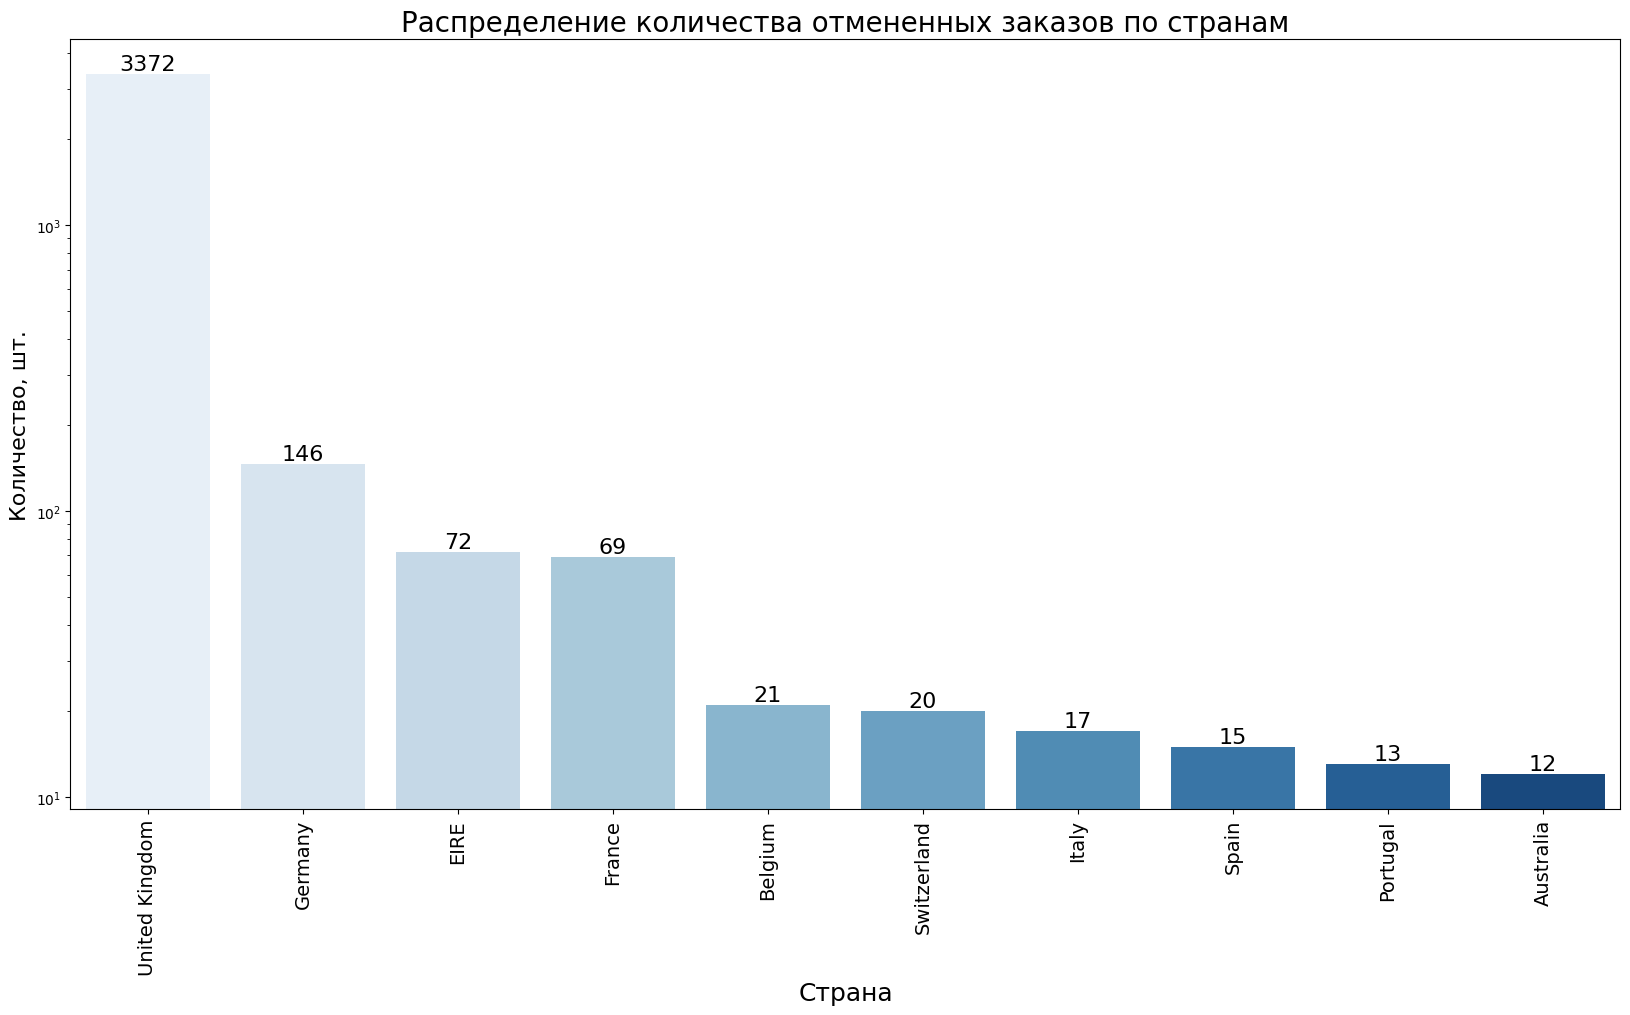

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x= 'Country', y = 'Number of cancels' , data = Number_of_cancels, palette = 'Blues')
for container in ax.containers :
 ax.bar_label (container, fontsize = 16)
plt.title("Раcпределение количества отмененных заказов по странам",fontsize=20)
plt.ylabel("Количество, шт.",fontsize = 16)
plt.xlabel('Страна',fontsize = 18)
plt.xticks(rotation=90, fontsize = 14)
plt.yscale('log')

In [ ]:
# Средний чек отмененного заказа по странам
AvgBill_cancel = InvCountry1.groupby('Country', as_index=False)['Total'].mean().sort_values('Total')
AvgBill_cancel.rename(columns= {'Total':'AvgBill_cancel'}, inplace = True)
AvgBill_cancel

,Country,AvgBill_cancel
24,Singapore,-4052.966667
14,Hong Kong,-1393.690000
28,USA,-924.735000
25,Spain,-453.502000
22,Portugal,-336.929231
8,EIRE,-279.821389
20,Norway,-250.495000
29,United Kingdom,-240.952488
17,Japan,-230.638889
15,Israel,-227.440000


In [ ]:
# средний чек отмененной покупки в целом
AvgBill_cancel['AvgBill_cancel'].mean()

-328.2554404006289

In [ ]:
# Общая сумма возврата по странам
TotalCancel = InvCountry1.groupby('Country', as_index=False)['Total'].sum().sort_values('Total')
TotalCancel.rename(columns= {'Total':'Totalsum_cancel'}, inplace = True)
TotalCancel

,Country,Totalsum_cancel
29,United Kingdom,-812491.79
8,EIRE,-20147.14
11,France,-12308.26
24,Singapore,-12158.90
12,Germany,-7168.93
25,Spain,-6802.53
14,Hong Kong,-5574.76
22,Portugal,-4380.08
17,Japan,-2075.75
28,USA,-1849.47


In [ ]:
TotalCancel['Totalsum_cancel'].sum() # Проверка. Общая сумма возврата

-893979.73

In [ ]:
# Объединим всю информацию по отменам в один датафрейм
Cancels = reduce(lambda a, b:a.merge(b, how = 'left', on = 'Country'), [Number_of_cancels, AvgBill_cancel, TotalCancel])
Cancels.head()

,Country,Number of cancels,AvgBill_cancel,Totalsum_cancel
0,United Kingdom,3372,-240.952488,-812491.79
1,Germany,146,-49.102260,-7168.93
2,EIRE,72,-279.821389,-20147.14
3,France,69,-178.380580,-12308.26
4,Belgium,21,-13.589524,-285.38


Выводы: Общий объём возвратов -893979,73 фунта. Это составляет 8,4% от общей выручки магазина (10 6310 48,74 у.е.). При этом в сумму возвратов входят банковские сборы, комиссии, сборы за обслуживание на сайте Амазона, скидки, почтовые расходы и образцы товаров). Таким образом, большая часть возвратов - это вероятно издержки содержания магазина(расходы).
Интересно, что по количеству отмененных заказов  помимо Великобритании, лидируют европейские страны: Германия, Ирландия, Франция, Бельгия, Швейцария. По общей сумме возвратов среди топ-10 стран появляются страны не из Европы Сингапур, Япония, Гонг-Конг, США. Причём количество заказов из этих стран небольшое. А средний чек возврата самый высокий. Посмотрим внимательнее, какой товар возвращали из этих стран?

In [ ]:
# Посмотрим, какие товары возвращали из этих стран
cancelled_purchases[cancelled_purchases['Country'] == 'Hong Kong']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
119631,C546557,M,Manual,-1,2011-03-15 09:44:00,2583.76,0.0,Hong Kong,09:44:00,Tuesday,2011-03,-2583.76
347947,C567352,M,Manual,-1,2011-09-19 16:13:00,2653.95,0.0,Hong Kong,16:13:00,Monday,2011-09,-2653.95
376126,C569495,21843,RED RETROSPOT CAKE STAND,-1,2011-10-04 13:43:00,10.95,0.0,Hong Kong,13:43:00,Tuesday,2011-10,-10.95
465423,C576233,M,Manual,-1,2011-11-14 13:26:00,326.10,0.0,Hong Kong,13:26:00,Monday,2011-11,-326.10


In [ ]:
cancelled_purchases[cancelled_purchases['Country'] == 'Singapore']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
144830,C548830,M,Manual,-1,2011-04-04 13:08:00,162.60,12744.0,Singapore,13:08:00,Monday,2011-04,-162.60
144831,C548830,M,Manual,-1,2011-04-04 13:08:00,2382.92,12744.0,Singapore,13:08:00,Monday,2011-04,-2382.92
144832,C548830,M,Manual,-1,2011-04-04 13:08:00,239.30,12744.0,Singapore,13:08:00,Monday,2011-04,-239.30
144833,C548830,M,Manual,-1,2011-04-04 13:08:00,1252.95,12744.0,Singapore,13:08:00,Monday,2011-04,-1252.95
144834,C548834,M,Manual,-1,2011-04-04 13:09:00,2053.07,12744.0,Singapore,13:09:00,Monday,2011-04,-2053.07
406404,C571750,M,Manual,-1,2011-10-19 11:16:00,3949.32,12744.0,Singapore,11:16:00,Wednesday,2011-10,-3949.32
406405,C571750,M,Manual,-1,2011-10-19 11:16:00,2118.74,12744.0,Singapore,11:16:00,Wednesday,2011-10,-2118.74


Возращали manual, что это означает не очень понятно.

**2. Анализ продаж в целом и по странам. Посмотрим данные о проданных товарах.**

In [ ]:
data = data[data['Quantity']>0] # Мы оставили в датафрейме только те строки, которые содержат данные о приобретенных товарах.

In [ ]:
data['Quantity'].min() # проверим минимальное количество товара в заказе

1

In [ ]:
data['Quantity'].max() # проверим максимальное количество товара в заказе.

80995

In [ ]:
data[data['Quantity'] == 80995] # посмотрим, что же заказали. Это бумажная птичка.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,09:15:00,Friday,2011-12,168469.6


In [ ]:
data['Quantity'].sum() # общее кол-во проданных товаров

5572419

**2.1 География продаж товаров**

In [ ]:
data['Country'].unique() # посмотрим в какие страны идут продажи

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Bahrain', 'Israel', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [ ]:
data[data['Country'] == 'Unspecified']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
152712,549687,20685,DOORMAT RED RETROSPOT,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified,13:29:00,Monday,2011-04,15.9
152713,549687,22691,DOORMAT WELCOME SUNRISE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified,13:29:00,Monday,2011-04,15.9
152714,549687,48116,DOORMAT MULTICOLOUR STRIPE,2,2011-04-11 13:29:00,7.95,12363.0,Unspecified,13:29:00,Monday,2011-04,15.9
152715,549687,21213,PACK OF 72 SKULL CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified,13:29:00,Monday,2011-04,13.2
152716,549687,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2011-04-11 13:29:00,0.55,12363.0,Unspecified,13:29:00,Monday,2011-04,13.2
...,...,...,...,...,...,...,...,...,...,...,...,...
498778,578539,22560,TRADITIONAL MODELLING CLAY,24,2011-11-24 14:55:00,1.25,0.0,Unspecified,14:55:00,Thursday,2011-11,30.0
498779,578539,23570,TRADITIONAL PICK UP STICKS GAME,12,2011-11-24 14:55:00,1.25,0.0,Unspecified,14:55:00,Thursday,2011-11,15.0
498780,578539,23571,TRADITIONAL NAUGHTS & CROSSES,12,2011-11-24 14:55:00,1.65,0.0,Unspecified,14:55:00,Thursday,2011-11,19.8
498781,578539,84992,72 SWEETHEART FAIRY CAKE CASES,24,2011-11-24 14:55:00,0.55,0.0,Unspecified,14:55:00,Thursday,2011-11,13.2


In [ ]:
data['Country'].nunique() # заказывают из 37 стран и одна категория под названием 'Unspecified'

38

Распределение общей выручки по странам

In [ ]:
# Подсчёт суммарной выручки по странам
totalGain = data.groupby('Country', as_index=False)['Total'].sum().sort_values('Total', ascending=False)
totalGain.rename(columns = {'Total':'Total gain'}, inplace = True)
totalGain

,Country,Total gain
36,United Kingdom,8990682.034
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


<ipython-input-46-7f56c4d4c6a8>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= 'Country', y = 'Total gain' , data = totalGain, palette = 'coolwarm')


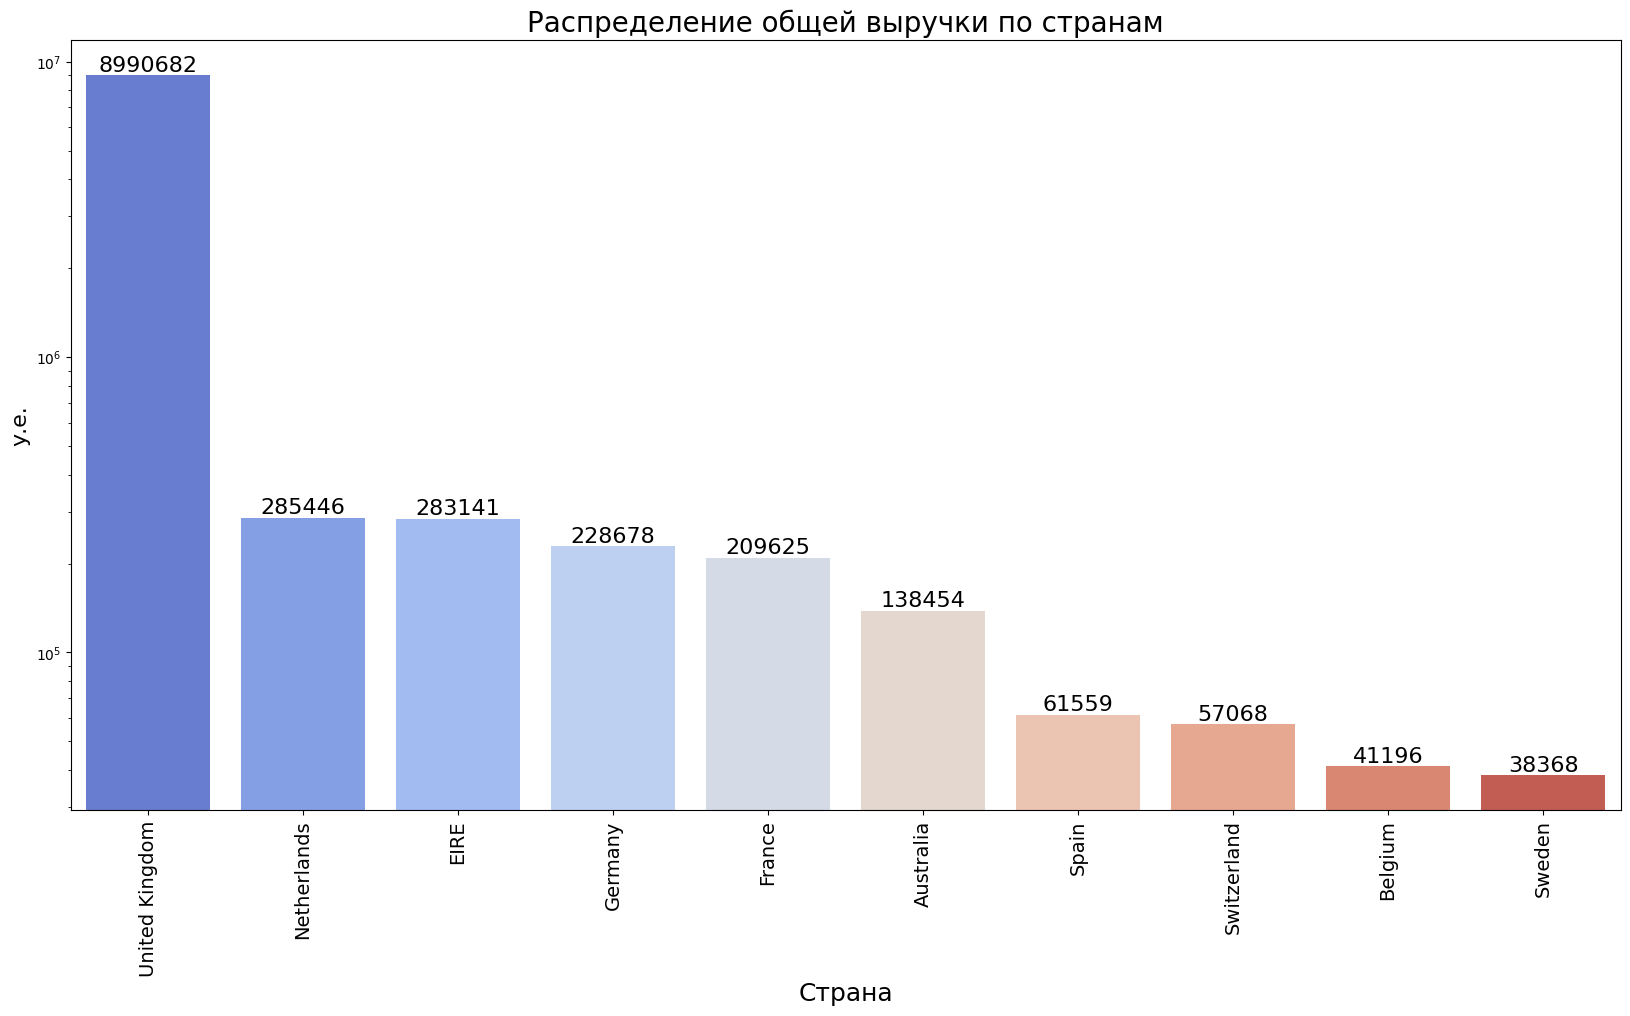

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x= 'Country', y = 'Total gain' , data = totalGain, palette = 'coolwarm')
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f', fontsize = 16)
plt.title("Раcпределение общей выручки по странам",fontsize=20)
plt.ylabel("у.е.",fontsize = 16)
plt.xlabel('Страна',fontsize = 18)
plt.xticks(rotation=90, fontsize = 14)
plt.yscale('log')

In [ ]:
totalGain['Total gain'].sum() # суммарная выручка магазина

10631048.743999999

In [ ]:
InvCountry = data.groupby(['Country', 'InvoiceNo'])[['Total']].sum().reset_index() # сгрупировали по номеру счёт-фактуры, посчитали сумму выручки для каждого чека
InvCountry

,Country,InvoiceNo,Total
0,Australia,536389,358.25
1,Australia,537676,258.90
2,Australia,539419,348.20
3,Australia,540267,7011.38
4,Australia,540280,143.00
...,...,...,...
19954,Unspecified,563947,252.90
19955,Unspecified,564051,278.13
19956,Unspecified,565303,284.30
19957,Unspecified,576646,333.20


In [ ]:
# Кол-во заказов по странам
Number_of_orders = InvCountry.groupby('Country', as_index=False).count()[['Country', 'InvoiceNo']].sort_values('InvoiceNo', ascending=False)
Number_of_orders.rename(columns = {'InvoiceNo':'Number of orders'}, inplace = True)
Number_of_orders

,Country,Number of orders
36,United Kingdom,18018
14,Germany,457
13,France,392
10,EIRE,288
3,Belgium,98
24,Netherlands,94
31,Spain,90
27,Portugal,58
0,Australia,57
33,Switzerland,54


<ipython-input-76-707c4aae94d6>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= 'Country', y = 'Number of orders', data = Number_of_orders, palette = 'PRGn_r')


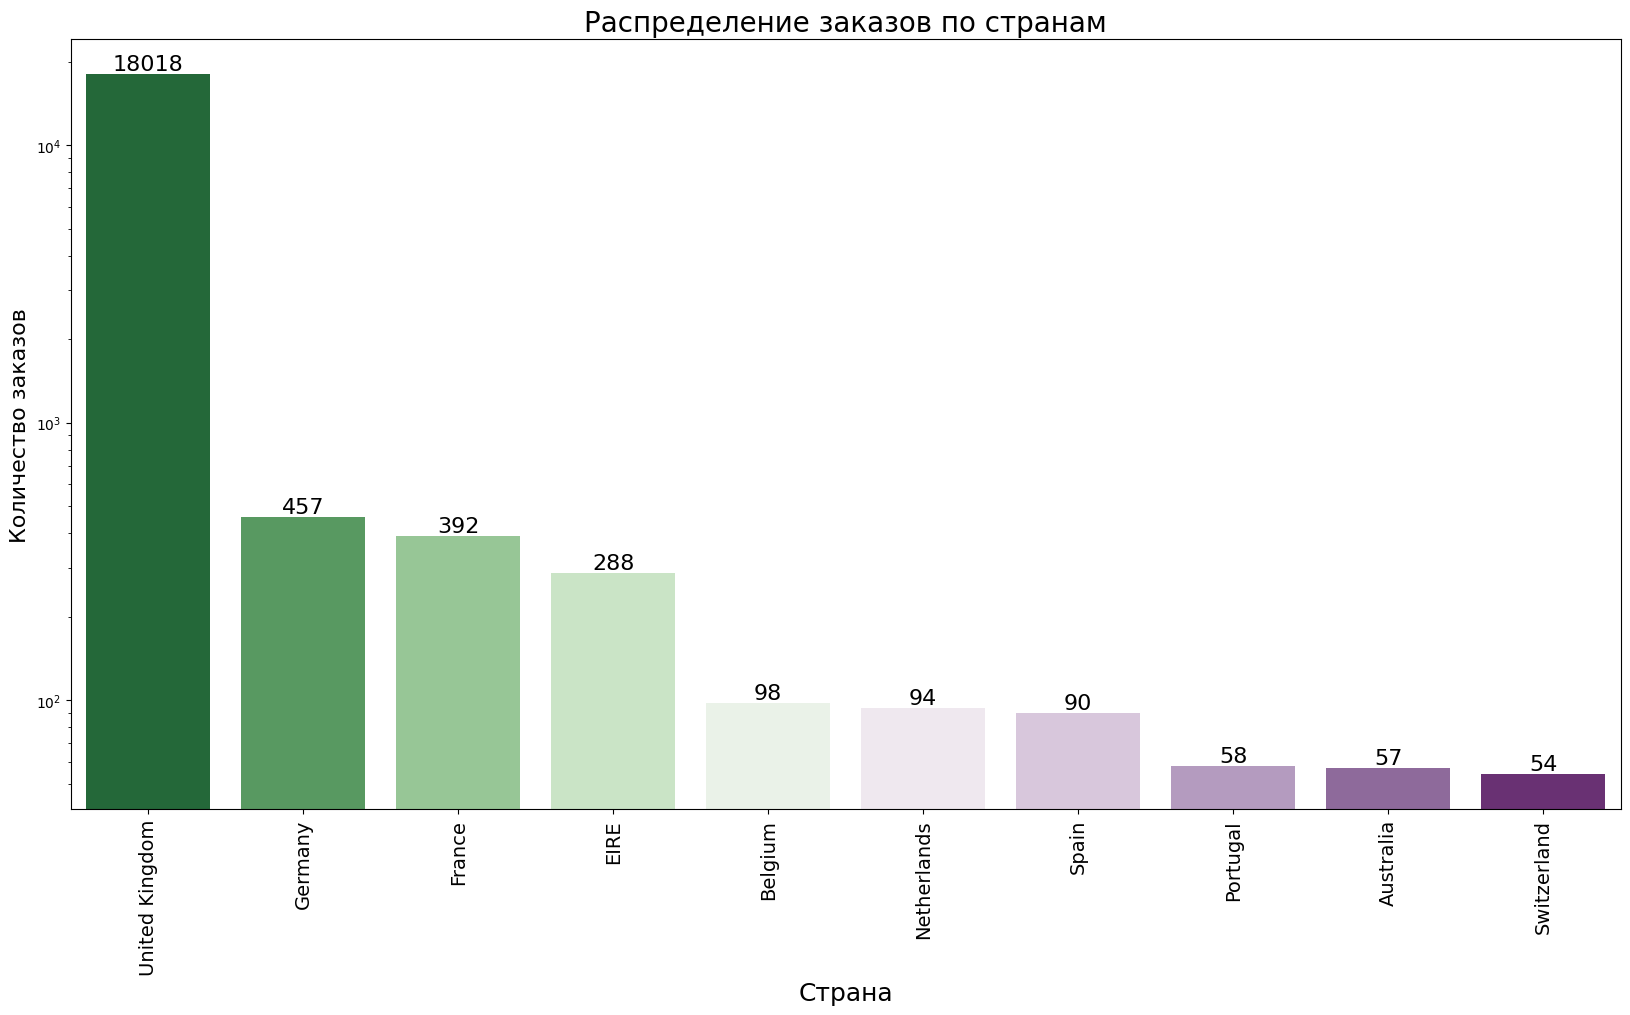

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x= 'Country', y = 'Number of orders', data = Number_of_orders, palette = 'PRGn_r')
for container in ax.containers :
 ax.bar_label (container, fontsize = 16 )
plt.title("Распределение заказов по странам",fontsize=20)
plt.ylabel("Количество заказов",fontsize = 16)
plt.xlabel('Страна',fontsize = 18)
plt.xticks(rotation=90, fontsize = 14)
plt.yscale('log')

In [ ]:
Number_of_orders['Number of orders'].sum() # Общее количество заказов

19959

In [ ]:
InvCountry['Total'].mean() # средний чек покупки в целом

532.644358134175

In [ ]:
# Средний чек по странам. Топ-10 стран
Average_bill = InvCountry.groupby('Country', as_index=False)['Total'].mean().sort_values('Total', ascending=False)
Average_bill.rename(columns = {'Total':'Average bill'}, inplace = True)
Average_bill

,Country,Average bill
30,Singapore,3039.898571
24,Netherlands,3036.663191
0,Australia,2429.014211
20,Japan,1969.282632
21,Lebanon,1693.880000
16,Hong Kong,1407.545455
4,Brazil,1143.600000
32,Sweden,1065.773056
33,Switzerland,1056.807407
9,Denmark,1053.074444


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Singapore'),
  Text(1, 0, 'Netherlands'),
  Text(2, 0, 'Australia'),
  Text(3, 0, 'Japan'),
  Text(4, 0, 'Lebanon'),
  Text(5, 0, 'Hong Kong'),
  Text(6, 0, 'Brazil'),
  Text(7, 0, 'Sweden'),
  Text(8, 0, 'Switzerland'),
  Text(9, 0, 'Denmark')])

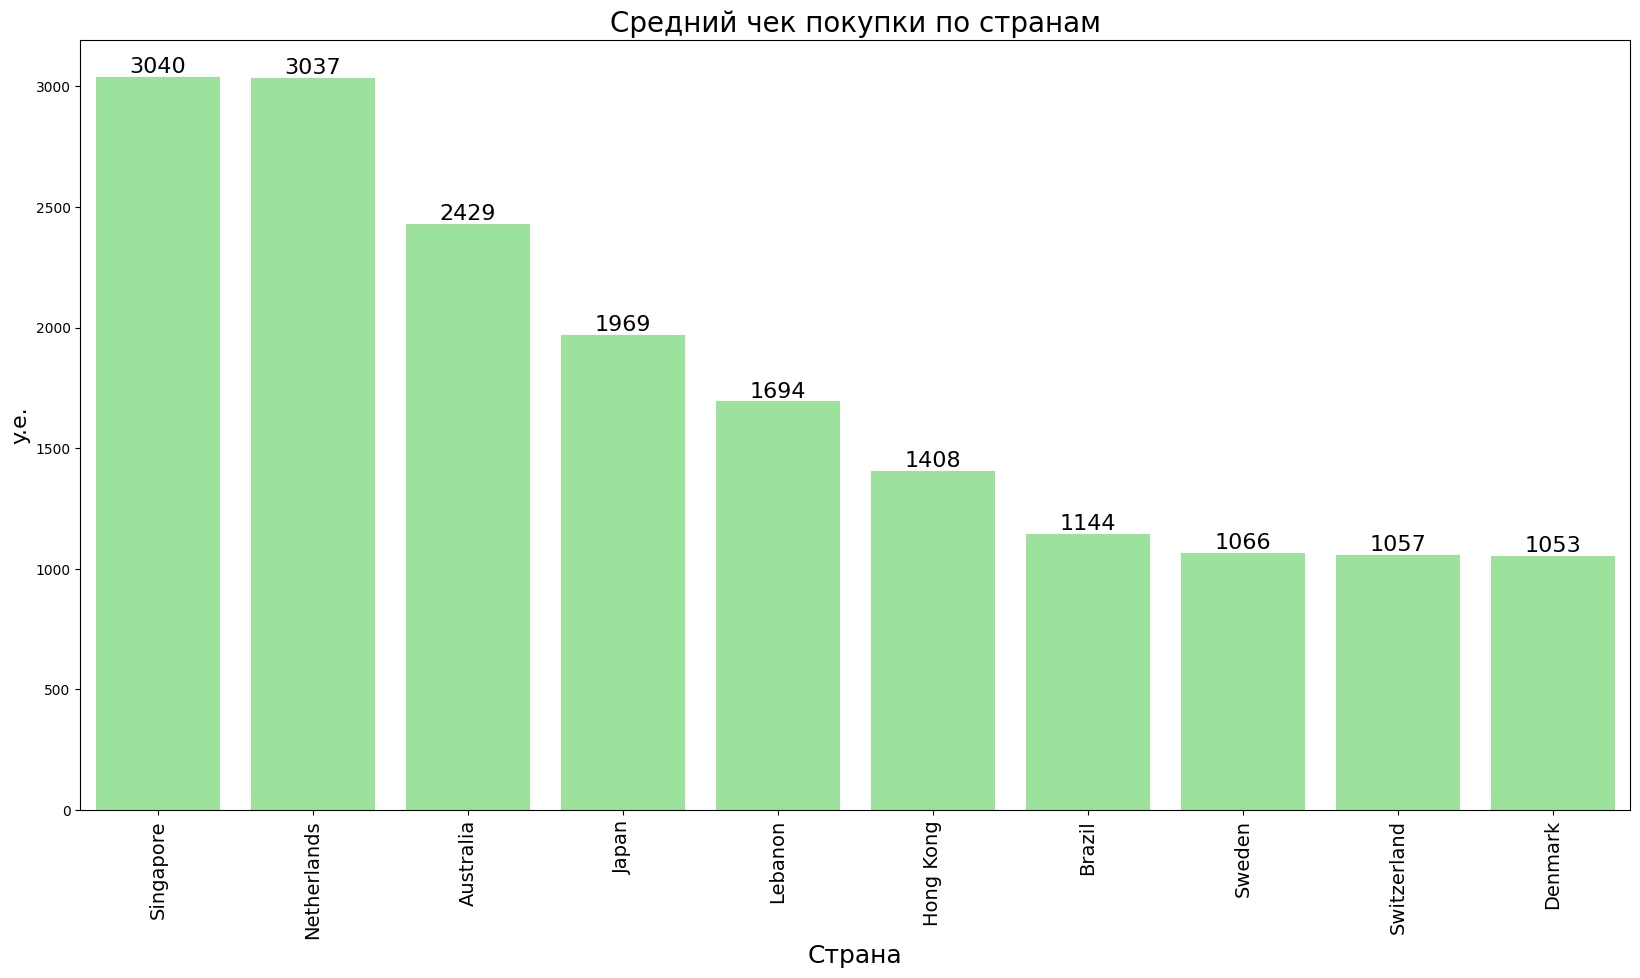

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x = 'Country', y = 'Average bill' , data = Average_bill, color = 'lightgreen')
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f', fontsize = 16)
plt.title("Средний чек покупки по странам",fontsize=20)
plt.ylabel("y.e.",fontsize = 16)
plt.xlabel('Страна',fontsize = 18)
plt.xticks(rotation=90, fontsize = 14)

In [ ]:
# Объединим всю информацию по выручке
Gain = reduce(lambda a, b:a.merge(b, how = 'left', on = 'Country'), [Number_of_orders, Average_bill, totalGain])
Gain.sort_values('Average bill', ascending = False).head(10)


,Country,Number of orders,Average bill,Total gain
24,Singapore,7,3039.898571,21279.29
5,Netherlands,94,3036.663191,285446.34
8,Australia,57,2429.014211,138453.81
15,Japan,19,1969.282632,37416.37
34,Lebanon,1,1693.880000,1693.88
21,Hong Kong,11,1407.545455,15483.00
35,Brazil,1,1143.600000,1143.60
13,Sweden,36,1065.773056,38367.83
9,Switzerland,54,1056.807407,57067.60
17,Denmark,18,1053.074444,18955.34


In [ ]:
# Объединим всю информацию по выручке и отмененным заказам в df
United_result = reduce(lambda a, b:a.merge(b, how = 'left', on = 'Country'), [Gain, Cancels])
United_result.sort_values('Average bill', ascending=False).head(10)


,Country,Number of orders,Average bill,Total gain,Number of cancels,AvgBill_cancel,Totalsum_cancel
24,Singapore,7,3039.898571,21279.29,3.0,-4052.966667,-12158.90
5,Netherlands,94,3036.663191,285446.34,6.0,-130.800000,-784.80
8,Australia,57,2429.014211,138453.81,12.0,-120.336667,-1444.04
15,Japan,19,1969.282632,37416.37,9.0,-230.638889,-2075.75
34,Lebanon,1,1693.880000,1693.88,NaN,NaN,NaN
21,Hong Kong,11,1407.545455,15483.00,4.0,-1393.690000,-5574.76
35,Brazil,1,1143.600000,1143.60,NaN,NaN,NaN
13,Sweden,36,1065.773056,38367.83,10.0,-178.242000,-1782.42
9,Switzerland,54,1056.807407,57067.60,20.0,-35.227500,-704.55
17,Denmark,18,1053.074444,18955.34,3.0,-62.400000,-187.20


Вывод по блоку: Общая выручка магазина составила 10631048,74. Наибольшая выручка поступает из Великобритании, откуда идёт основная часть заказов. Также в топ-10 стран по общей выручке попали в основном страны из Европы: Нидерланды, Ирландия, Германия, Франция, Испания и Австралия), откуда идёт основная часть заказов. По количеству заказов эти страны также лидируют. При этом средний чек покупки выше в странах, находящихся за пределами Европы (Сингапур, Австралия, Япония, Гонг Конг, Ливия). Вероятно из-за расстояния (срок доставки, стоимость доставки) покупатели предпочитают делать сразу крупный заказ.

**3. Анализ наиболее и наименее популярных товаров**

In [ ]:
data.groupby(['Description', 'UnitPrice']).agg({'UnitPrice':['min', 'max'], 'Quantity':'sum', 'Total': 'sum'}).head(15)


UnitPrice        Quantity    Total
                                               min    max      sum      sum
Description                    UnitPrice                                   
 4 PURPLE FLOCK DINNER CANDLES 0.79           0.79   0.79       49    38.71
                               2.55           2.55   2.55       89   226.95
                               4.96           4.96   4.96        2     9.92
                               5.06           5.06   5.06        2    10.12
 50'S CHRISTMAS GIFT BAG LARGE 1.04           1.04   1.04      400   416.00
                               1.25           1.25   1.25     1487  1858.75
                               2.46           2.46   2.46       28    68.88
 DOLLY GIRL BEAKER             1.08           1.08   1.08     1400  1512.00
                               1.25           1.25   1.25     1001  1251.25
                               2.46           2.46   2.46       50   123.00
 I LOVE LONDON MINI BACKPACK   3.75           3.75   3.75      100   375.00
                               4.15           4.15   4.15      275  1141.25
                               8.29           8.29   8.29       13   107.77
 I LOVE LONDON MINI RUCKSACK   4.15           4.15   4.15        1     4.15
 NINE DRAWER OFFICE TIDY       12.50         12.50  12.50       12   150.00

Мы видим, что цена на товар неодинаковая. Чем меньше цена, тем большее количество товара было продано. Скорее всего действуют оптовые скидки при покупке свыше определенного количества товара. Цена в розницу и оптовая цена различаются почти в два раза.
Кроме того, скорее всего за исследуемый период было небольшое повышение цен. В декабре 2010 цена была одна, а уже в ноябре 2011 было повышение цен.      

In [ ]:
# наиболее популярные товары
data['Description'].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2311
JUMBO BAG RED RETROSPOT               2109
REGENCY CAKESTAND 3 TIER              2007
PARTY BUNTING                         1699
LUNCH BAG RED RETROSPOT               1581
ASSORTED COLOUR BIRD ORNAMENT         1476
SET OF 3 CAKE TINS PANTRY DESIGN      1392
PACK OF 72 RETROSPOT CAKE CASES       1352
LUNCH BAG  BLACK SKULL.               1301
NATURAL SLATE HEART CHALKBOARD        1255
Name: count, dtype: int64

In [ ]:
# Top-10 наиболее популярных(продаваемых) товаров по количеству
SoldMost = data.groupby('Description', as_index = False)[['Quantity', 'Total']].sum().sort_values('Quantity', ascending = False).head(10)
SoldMost

,Description,Quantity,Total
2386,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60
2051,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92
3933,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01
1815,JUMBO BAG RED RETROSPOT,48371,94159.81
3843,WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
2680,POPCORN HOLDER,36749,34288.67
2336,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45
227,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62
2740,RABBIT NIGHT LIGHT,30739,66870.03
2106,MINI PAINT SET VINTAGE,26633,16937.82


In [ ]:
data[data['Description'] == 'PAPER CRAFT , LITTLE BIRDIE']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,09:15:00,Friday,2011-12,168469.6


Этот же товар был в Топ-10 среди отмененных покупок

In [ ]:
cancelled_purchases[cancelled_purchases['Description'] == 'PAPER CRAFT , LITTLE BIRDIE']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,09:27:00,Friday,2011-12,-168469.6


Cамый покупаемый товар купили крупной партией и через 15 минут сдали обратно.

In [ ]:
# Проверили второй по популярности товар, его также купили крупной партией и вернули обратно. Второй в списке среди возвращённых товаров.
cancelled_purchases[cancelled_purchases['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,10:17:00,Tuesday,2011-01,-77183.60
203625,C554527,23166,MEDIUM CERAMIC TOP STORAGE JAR,-9,2011-05-24 17:25:00,1.04,15251.0,United Kingdom,17:25:00,Tuesday,2011-05,-9.36
234364,C557508,23166,MEDIUM CERAMIC TOP STORAGE JAR,-240,2011-06-20 16:13:00,1.04,16684.0,United Kingdom,16:13:00,Monday,2011-06,-249.60
270084,C560540,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,2011-07-19 12:26:00,1.25,12415.0,Australia,12:26:00,Tuesday,2011-07,-1.25
290357,C562375,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,2011-08-04 14:46:00,1.25,14911.0,EIRE,14:46:00,Thursday,2011-08,-15.00
297530,C562952,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,2011-08-11 10:10:00,1.25,12749.0,United Kingdom,10:10:00,Thursday,2011-08,-1.25
349848,C567535,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,2011-09-21 09:50:00,1.25,15253.0,United Kingdom,09:50:00,Wednesday,2011-09,-1.25
352712,C567677,23166,MEDIUM CERAMIC TOP STORAGE JAR,-2,2011-09-21 15:57:00,1.04,12409.0,Switzerland,15:57:00,Wednesday,2011-09,-2.08
394002,C570867,23166,MEDIUM CERAMIC TOP STORAGE JAR,-12,2011-10-12 16:17:00,1.25,12607.0,USA,16:17:00,Wednesday,2011-10,-15.00
421501,C572991,23166,MEDIUM CERAMIC TOP STORAGE JAR,-1,2011-10-27 10:56:00,1.25,17672.0,United Kingdom,10:56:00,Thursday,2011-10,-1.25


In [ ]:
data[(data['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR')&(data['CustomerID'] == 12346.0)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,10:01:00,Tuesday,2011-01,77183.6


Второй по популярности товар также купили крупной партией и почти сразу вернули, через 15 минут. По какой причине возвращают такие большие партии товаров?

In [ ]:
# Удалим строчки с этими товарами, чтобы они не искажали картину.
data.drop(data.loc[(data['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR')&(data['CustomerID'] == 12346.0)|(data['Description'] == 'PAPER CRAFT , LITTLE BIRDIE')].index, inplace=True)


In [ ]:
# проверка. Строки удалились из датафрейма
data[(data['Description'] == 'MEDIUM CERAMIC TOP STORAGE JAR')&(data['CustomerID'] == 12346.0)|(data['Description'] == 'PAPER CRAFT , LITTLE BIRDIE')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total


In [ ]:
# новый Top-10 наиболее популярных(продаваемых) товаров
SoldMost_upd = data.groupby('Description', as_index = False)[['Quantity', 'Total']].sum().sort_values('Quantity', ascending = False).head(10)
SoldMost_upd

,Description,Quantity,Total
3932,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01
1815,JUMBO BAG RED RETROSPOT,48371,94159.81
3842,WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
2679,POPCORN HOLDER,36749,34288.67
2336,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45
227,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62
2739,RABBIT NIGHT LIGHT,30739,66870.03
2106,MINI PAINT SET VINTAGE,26633,16937.82
2302,PACK OF 12 LONDON TISSUES,26119,7975.98
2334,PACK OF 60 PINK PAISLEY CAKE CASES,24820,12226.32


In [ ]:
# через фильтр можно проверить сколько раз возвращали товар. Действительно ли его купили больше раз, чем вернули
cancelled_purchases[(cancelled_purchases['Description'] == 'WHITE HANGING HEART T-LIGHT HOLDER')]['Quantity'].sum()

-2578

<ipython-input-103-c498321c3d47>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(y = 'Description' , x= 'Quantity' , data = SoldMost_upd, palette = Palette)
<ipython-input-103-c498321c3d47>:6: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax =sns.barplot(y = 'Description' , x= 'Quantity' , data = SoldMost_upd, palette = Palette)


Text(0.5, 0, 'Количество')

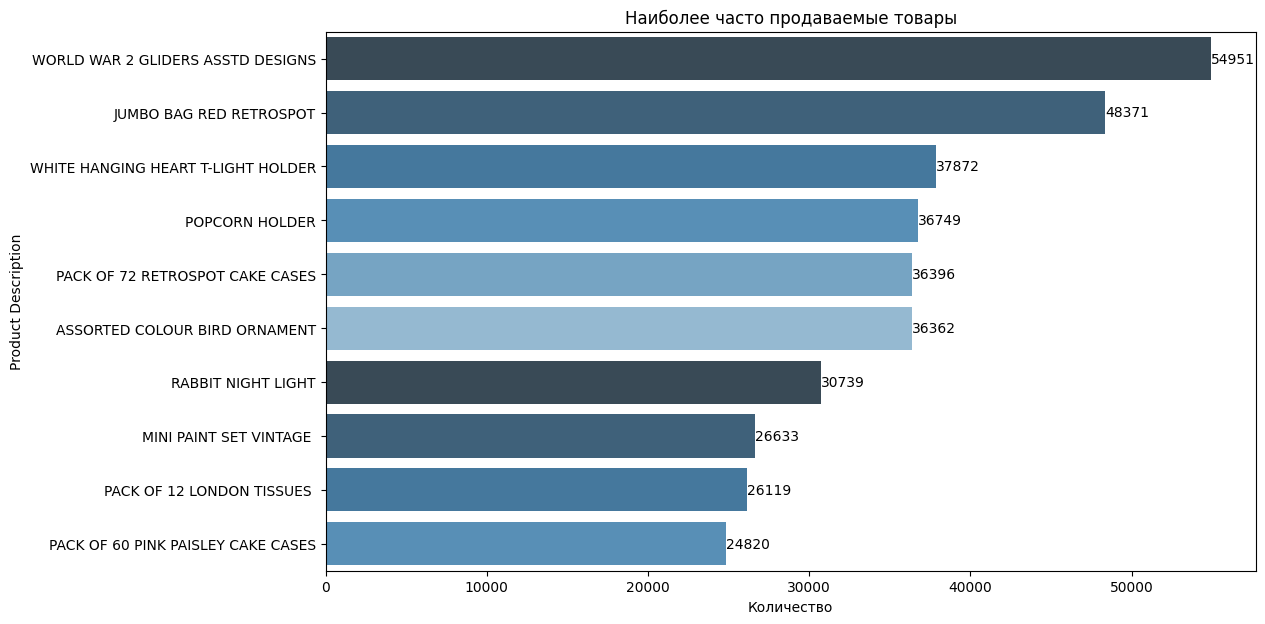

In [ ]:
#Choosing Palette and reverse it
Palette = sns.color_palette('Blues_d')
Palette.reverse()
plt.figure(figsize = (12,7))
#Visualizing
ax =sns.barplot(y = 'Description' , x= 'Quantity' , data = SoldMost_upd, palette = Palette)
#Data labels
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f')
#Setting Title
plt.title('Наиболее часто продаваемые товары')
plt.ylabel('Product Description')
plt.xlabel('Количество')

In [ ]:
# Top-10 товаров,принесших наибольшую выручку компании
MaxGain = data.groupby('Description', as_index = False)[['Quantity', 'Total']].sum().sort_values('Total', ascending = False).head(10)
MaxGain

,Description,Quantity,Total
1066,DOTCOM POSTAGE,706,206248.77
2851,REGENCY CAKESTAND 3 TIER,13851,174156.54
3842,WHITE HANGING HEART T-LIGHT HOLDER,37872,106236.72
2411,PARTY BUNTING,18283,99445.23
1815,JUMBO BAG RED RETROSPOT,48371,94159.81
2690,POSTAGE,3150,78101.88
2191,Manual,6985,77752.82
2739,RABBIT NIGHT LIGHT,30739,66870.03
2380,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59
227,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62


На первом месте по-видимому оплата почтовых расходов за доставку, manual также есть в этом списке.

<ipython-input-109-59ad63d60ddd>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax =sns.barplot(y = 'Description' , x= 'Total' , data = MaxGain, palette = Palette)
<ipython-input-109-59ad63d60ddd>:6: UserWarning: 
The palette list has fewer values (6) than needed (10) and will cycle, which may produce an uninterpretable plot.
  ax =sns.barplot(y = 'Description' , x= 'Total' , data = MaxGain, palette = Palette)


Text(0, 0.5, 'Product Description')

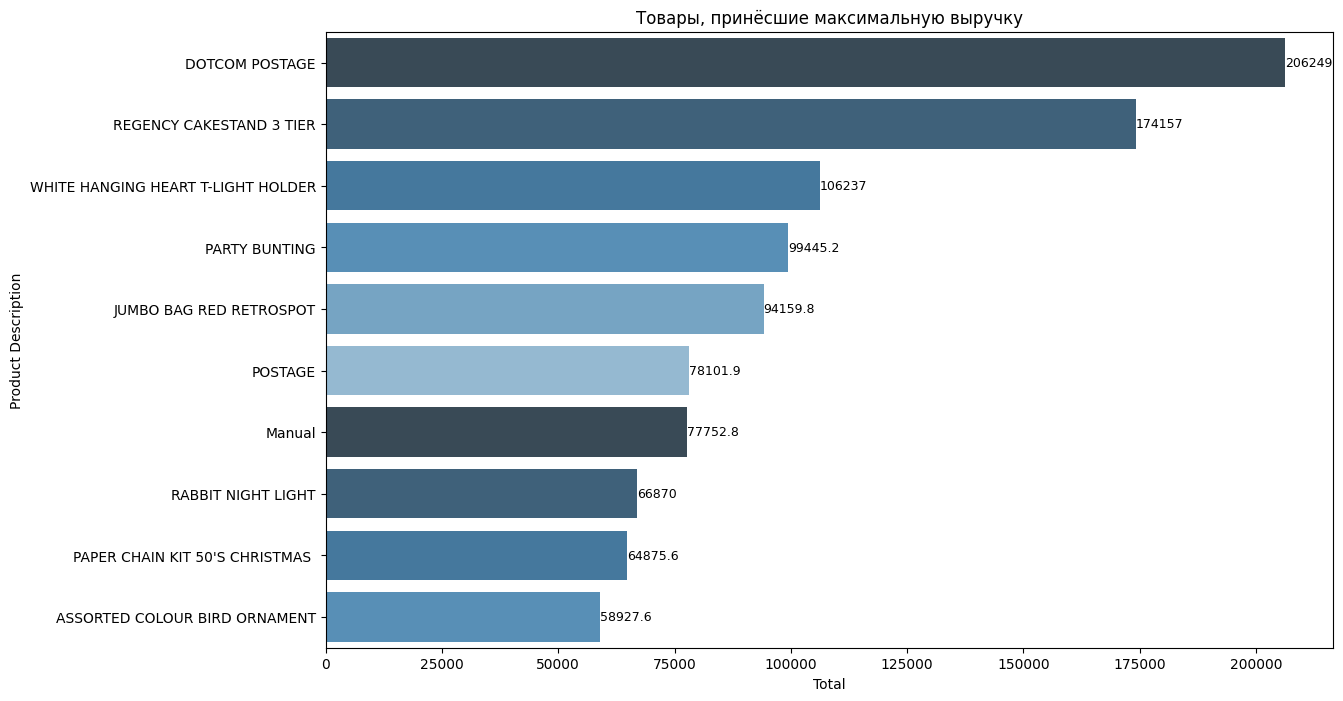

In [ ]:
#Choosing Palette and reverse it
Palette = sns.color_palette('Blues_d')
Palette.reverse()
plt.figure(figsize = (13, 8))
#Visualizing
ax =sns.barplot(y = 'Description' , x= 'Total' , data = MaxGain, palette = Palette)
#Data labels
for container in ax.containers :
 ax.bar_label (container, fontsize = 9)
#Setting Title
plt.title('Товары, принёсшие максимальную выручку')
plt.ylabel('Product Description')

**4. Динамика продаж (анализ динамики продаж по месяцам, дням недели и часам)**

4.1. Динамика продаж по месяцам

In [ ]:
data['Year_month'].unique() # посмотрим за какой период есть данные

<PeriodArray>
['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06',
 '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12']
Length: 13, dtype: period[M]

In [ ]:
data[data['Year_month']== '2010-12'] # за 2010 год есть данные только за декабрь

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34
...,...,...,...,...,...,...,...,...,...,...,...,...
42476,539991,21618,4 WILDFLOWER BOTANICAL CANDLES,1,2010-12-23 16:49:00,1.25,0.0,United Kingdom,16:49:00,Thursday,2010-12,1.25
42477,539991,72741,GRAND CHOCOLATECANDLE,4,2010-12-23 16:49:00,1.45,0.0,United Kingdom,16:49:00,Thursday,2010-12,5.80
42478,539992,21470,FLOWER VINE RAFFIA FOOD COVER,1,2010-12-23 17:41:00,3.75,0.0,United Kingdom,17:41:00,Thursday,2010-12,3.75
42479,539992,22258,FELT FARM ANIMAL RABBIT,1,2010-12-23 17:41:00,1.25,0.0,United Kingdom,17:41:00,Thursday,2010-12,1.25


За 2010 год данные по продажам есть только за декабрь за период с 1.12 по 23.12.

In [ ]:
data[data['Year_month'] == '2010-12'][['Total']].sum().reset_index() # выручка за декабрь 2010 года

,index,0
0,Total,821452.73


In [ ]:
data[(data['Year_month']=='2011-12')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total
516403,579899,23301,GARDENERS KNEELING PAD KEEP CALM,24,2011-12-01 08:33:00,1.65,15687.0,United Kingdom,08:33:00,Thursday,2011-12,39.60
516404,579899,22623,BOX OF VINTAGE JIGSAW BLOCKS,3,2011-12-01 08:33:00,5.95,15687.0,United Kingdom,08:33:00,Thursday,2011-12,17.85
516405,579899,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,4,2011-12-01 08:33:00,3.75,15687.0,United Kingdom,08:33:00,Thursday,2011-12,15.00
516406,579899,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-01 08:33:00,2.89,15687.0,United Kingdom,08:33:00,Thursday,2011-12,17.34
516407,579899,71477,COLOURED GLASS STAR T-LIGHT HOLDER,4,2011-12-01 08:33:00,3.95,15687.0,United Kingdom,08:33:00,Thursday,2011-12,15.80
...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,12:50:00,Friday,2011-12,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12:50:00,Friday,2011-12,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60


За декабрь 2011 года данные неполные. Данные есть только за период с 1-09.12

In [ ]:
data[data['Year_month'] == '2011-12'][['Total']].sum().reset_index()

,index,0
0,Total,469320.73


За декабрь 2011 выручка в два раза меньше, чем в 2010 году из-за неполноты данных за декабрь

In [ ]:
# Посчитаем общую выручку по месяцам
sales = data.groupby('Year_month')[['Total']].sum().reset_index()
sales

,Year_month,Total
0,2010-12,821452.730
1,2011-01,612628.010
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,746779.320
9,2011-09,1056435.192


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2010-12'),
  Text(1, 0, '2011-01'),
  Text(2, 0, '2011-02'),
  Text(3, 0, '2011-03'),
  Text(4, 0, '2011-04'),
  Text(5, 0, '2011-05'),
  Text(6, 0, '2011-06'),
  Text(7, 0, '2011-07'),
  Text(8, 0, '2011-08'),
  Text(9, 0, '2011-09'),
  Text(10, 0, '2011-10'),
  Text(11, 0, '2011-11'),
  Text(12, 0, '2011-12')])

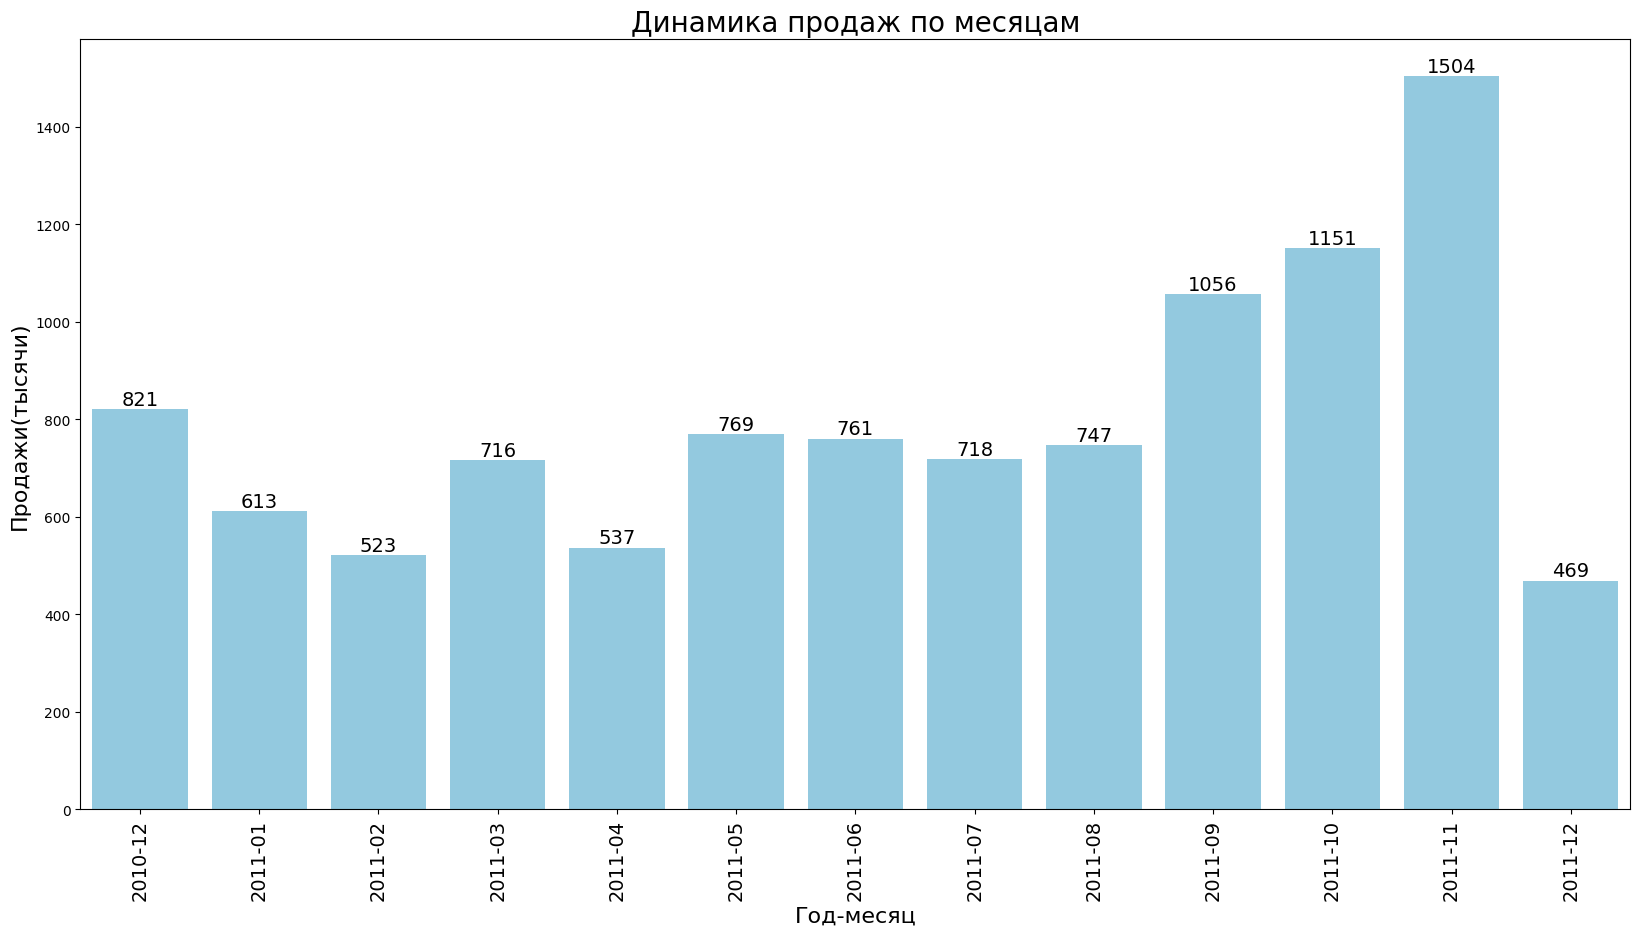

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x = 'Year_month', y = sales['Total']/1000, data = sales, color = 'skyblue')
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f', fontsize = 14)
plt.title("Динамика продаж по месяцам",fontsize=20)
plt.ylabel("Продажи(тысячи)",fontsize = 16)
plt.xlabel('Год-месяц',fontsize = 16)
plt.xticks(rotation=90, fontsize = 14)

Вывод: Данные за 2010 год есть только за декабрь. В 2011 году самые высокие продажи были в ноябре. Из графика видно, что начиная с сентября начинают расти продажи, достигая максимума в ноябре. В декабре 2011 продажи падают, при этом в декабре 2010 года продажи были почти в два раза выше. Это связано с тем, что данные за декабрь 2011 года неполные с 1.12 по 9.12. Возможно максимальные продажи могли быть в декабре 2011 года. Также возможно, что покупатели готовятся к НГ праздникам и Рождеству и закупают товары заблаговременно. Самые минимальные продажи были в феврале и апреле. В остальные месяцы общий объем продаж держится примерно на одном уровне около 700.тыс.

In [ ]:
InvMonth = data.groupby(['Year_month','InvoiceNo'])[['Total']].sum().reset_index()
InvMonth

,Year_month,InvoiceNo,Total
0,2010-12,536365,139.12
1,2010-12,536366,22.20
2,2010-12,536367,278.73
3,2010-12,536368,70.05
4,2010-12,536369,17.85
...,...,...,...
19952,2011-12,581583,124.60
19953,2011-12,581584,140.64
19954,2011-12,581585,329.05
19955,2011-12,581586,339.20


In [ ]:
sales_m = InvMonth.groupby('Year_month')[['Total']].sum().reset_index()
sales_m

,Year_month,Total
0,2010-12,821452.730
1,2011-01,612628.010
2,2011-02,522545.560
3,2011-03,716215.260
4,2011-04,536968.491
5,2011-05,769296.610
6,2011-06,760547.010
7,2011-07,718076.121
8,2011-08,746779.320
9,2011-09,1056435.192


In [ ]:
# среднемесячная выручка магазина
sales_m['Total'].mean()

798876.5803076923

In [ ]:
# Количество заказов в месяц
Number_of_orders_perMonth = InvMonth.groupby('Year_month')[['InvoiceNo']].count().reset_index()
Number_of_orders_perMonth

,Year_month,InvoiceNo
0,2010-12,1559
1,2011-01,1085
2,2011-02,1100
3,2011-03,1454
4,2011-04,1246
5,2011-05,1681
6,2011-06,1533
7,2011-07,1475
8,2011-08,1360
9,2011-09,1837


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2010-12'),
  Text(1, 0, '2011-01'),
  Text(2, 0, '2011-02'),
  Text(3, 0, '2011-03'),
  Text(4, 0, '2011-04'),
  Text(5, 0, '2011-05'),
  Text(6, 0, '2011-06'),
  Text(7, 0, '2011-07'),
  Text(8, 0, '2011-08'),
  Text(9, 0, '2011-09'),
  Text(10, 0, '2011-10'),
  Text(11, 0, '2011-11'),
  Text(12, 0, '2011-12')])

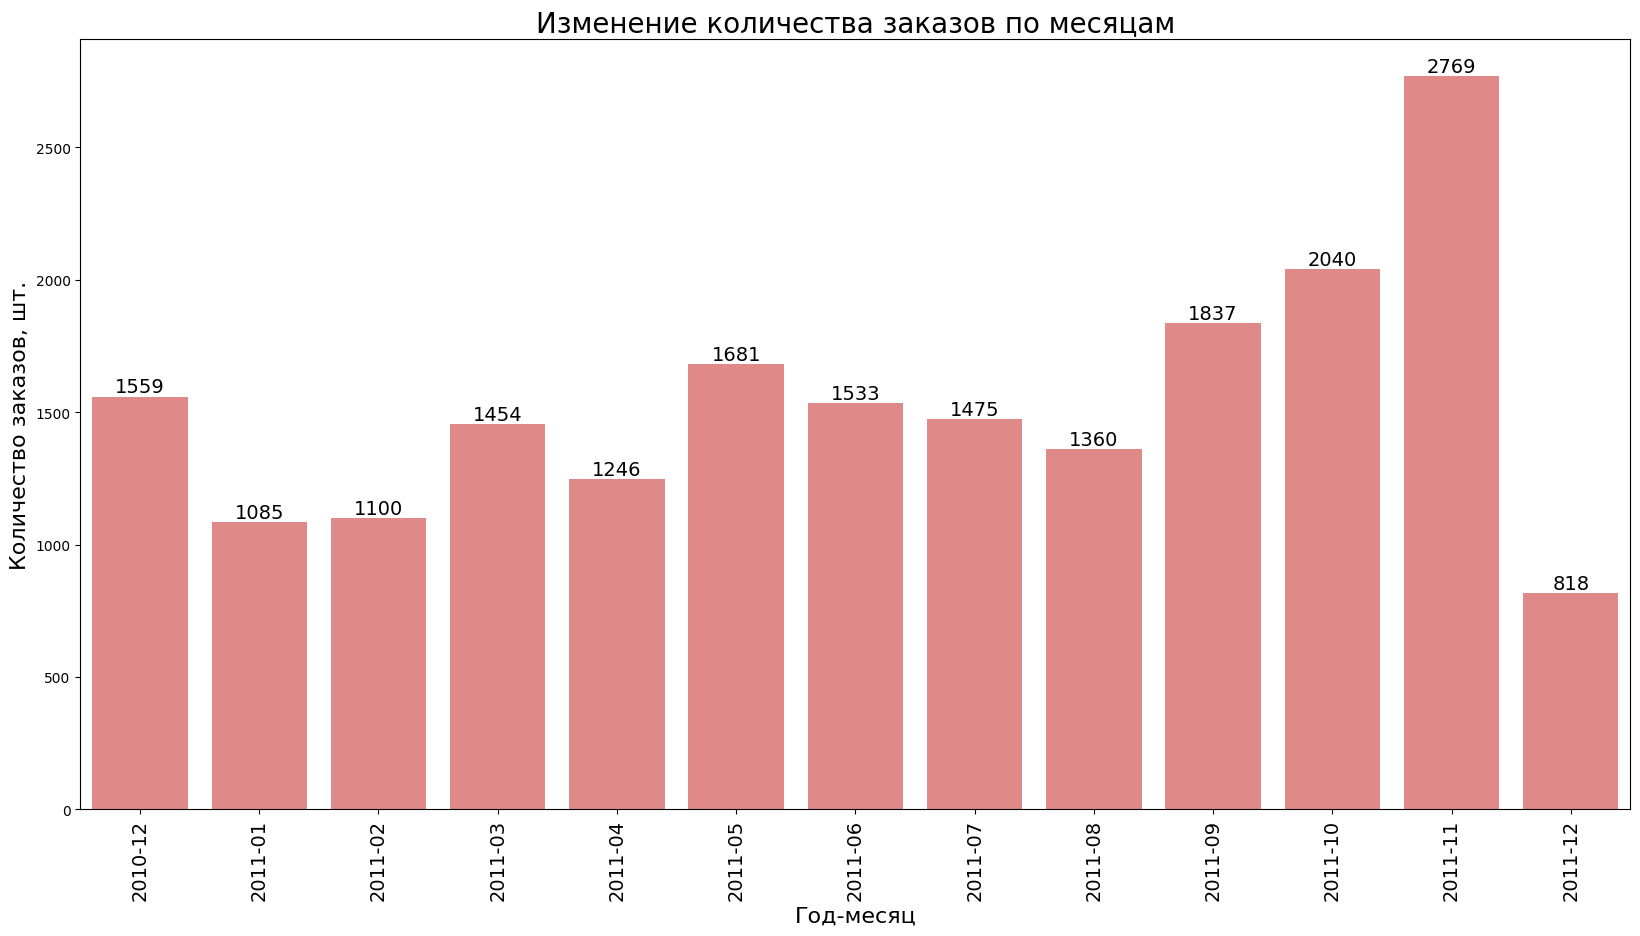

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x = 'Year_month', y = 'InvoiceNo', data = Number_of_orders_perMonth, color = '#ED7B7B')
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f', fontsize = 14)
plt.title("Изменение количества заказов по месяцам",fontsize=20)
plt.ylabel("Количество заказов, шт.", fontsize = 16)
plt.xlabel('Год-месяц',fontsize = 16)
plt.xticks(rotation=90, fontsize = 14)

Количество заказов как и выручка максимально в ноябре. Все осенние месяцы характеризуются высоким количеством заказов. Минимальное количество заказов в декабре, что скорее всего связано с неполными данными за этот месяц. В зимние месяцы наблюдается снижение количества заказов по сравнению с другими месяцами. Весной количество заказов растет и остается примерно одинаковым в течение лета.

In [ ]:
# средний чек по месяцам
AvgBill = InvMonth.groupby('Year_month')[['Total']].mean().reset_index()
AvgBill

,Year_month,Total
0,2010-12,526.910026
1,2011-01,564.634111
2,2011-02,475.041418
3,2011-03,492.582710
4,2011-04,430.953845
5,2011-05,457.642243
6,2011-06,496.116771
7,2011-07,486.831268
8,2011-08,549.102441
9,2011-09,575.087203


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, '2010-12'),
  Text(1, 0, '2011-01'),
  Text(2, 0, '2011-02'),
  Text(3, 0, '2011-03'),
  Text(4, 0, '2011-04'),
  Text(5, 0, '2011-05'),
  Text(6, 0, '2011-06'),
  Text(7, 0, '2011-07'),
  Text(8, 0, '2011-08'),
  Text(9, 0, '2011-09'),
  Text(10, 0, '2011-10'),
  Text(11, 0, '2011-11'),
  Text(12, 0, '2011-12')])

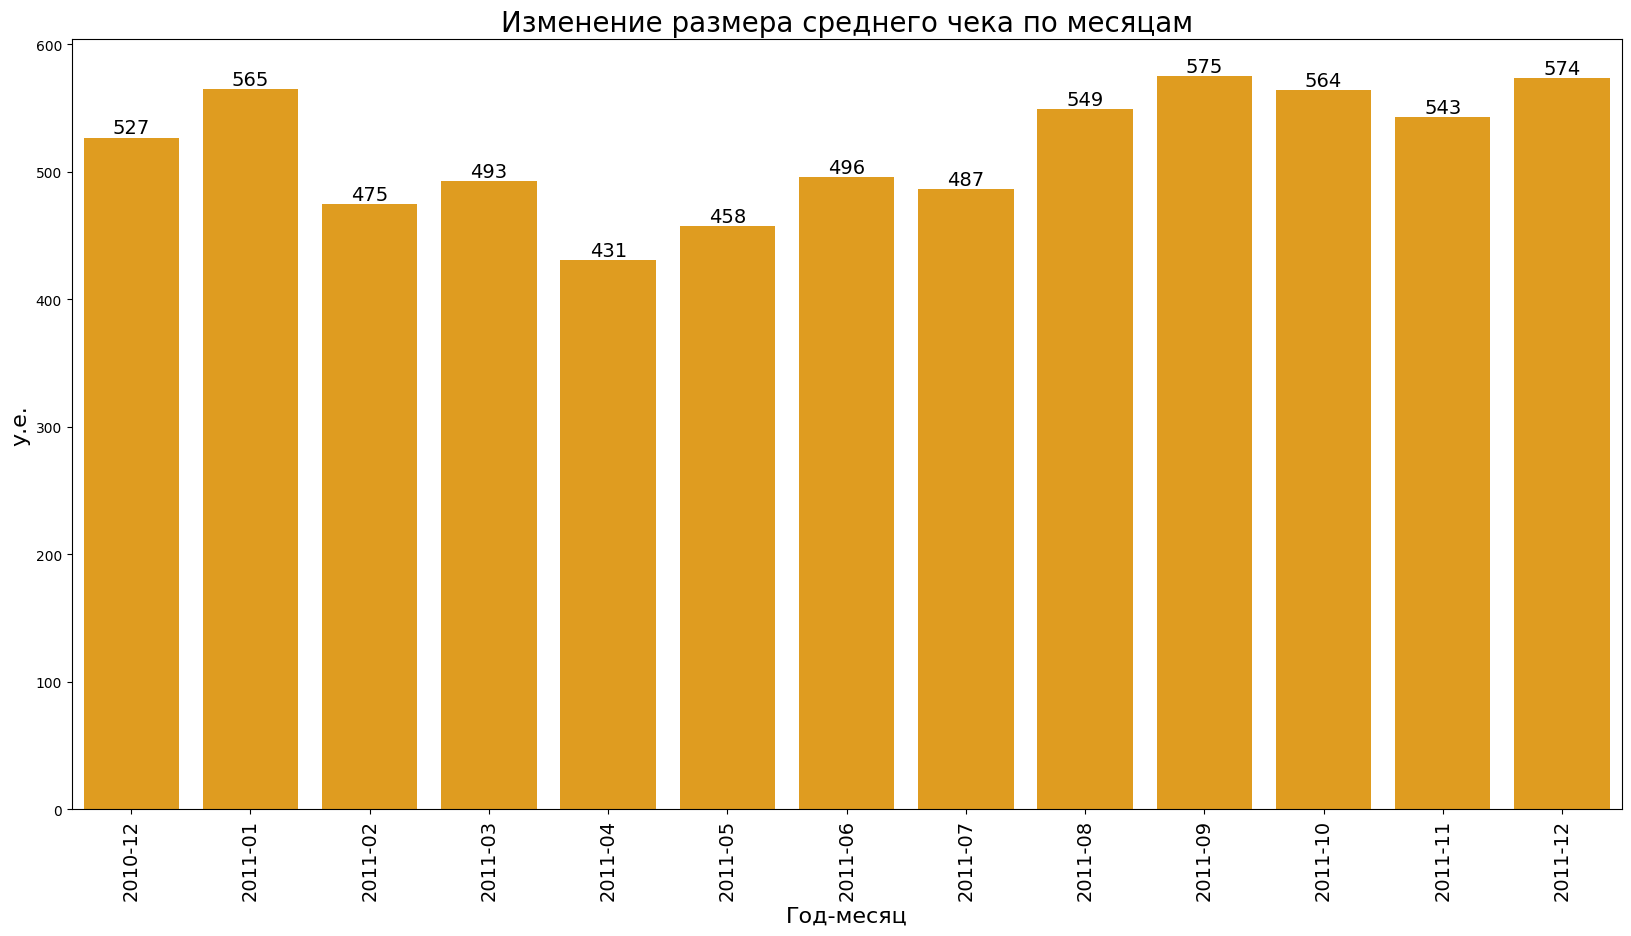

In [ ]:
plt.figure(figsize = (20,10))
ax = sns.barplot(x = 'Year_month', y = 'Total', data = AvgBill, color = 'orange')
for container in ax.containers :
 ax.bar_label (container, fmt = '%.0f', fontsize = 14)
plt.title("Изменение размера среднего чека по месяцам",fontsize=20)
plt.ylabel("у.е.",fontsize = 16)
plt.xlabel('Год-месяц',fontsize = 16)
plt.xticks(rotation=90, fontsize = 14)

In [ ]:
# размер среднего чека за исследуемый период
AvgBill['Total'].mean()

518.1613067747437

4.2. Динамика продаж по дням недели

In [ ]:
data['Day'].unique()

array(['Wednesday', 'Thursday', 'Friday', 'Sunday', 'Monday', 'Tuesday'],
      dtype=object)

In [ ]:
data[data['Day']=='Saturday']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total


Нет данных по продажам за субботы, что странно.

In [ ]:
# общая выручка по дням недели
DayTotal = data.groupby('Day')[['Total']].sum().reset_index()
DayTotal

,Day,Total
0,Friday,1657938.831
1,Monday,1775782.071
2,Sunday,806790.781
3,Thursday,2199292.570
4,Tuesday,2098516.911
5,Wednesday,1847074.380


In [ ]:
# сделаем сортировку по дням недели
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
DayTotal['Day'] = pd.Categorical(DayTotal['Day'], categories=cats, ordered=True)
DayTotal = DayTotal.sort_values('Day')
DayTotal

,Day,Total
1,Monday,1775782.071
4,Tuesday,2098516.911
5,Wednesday,1847074.380
3,Thursday,2199292.570
0,Friday,1657938.831
2,Sunday,806790.781


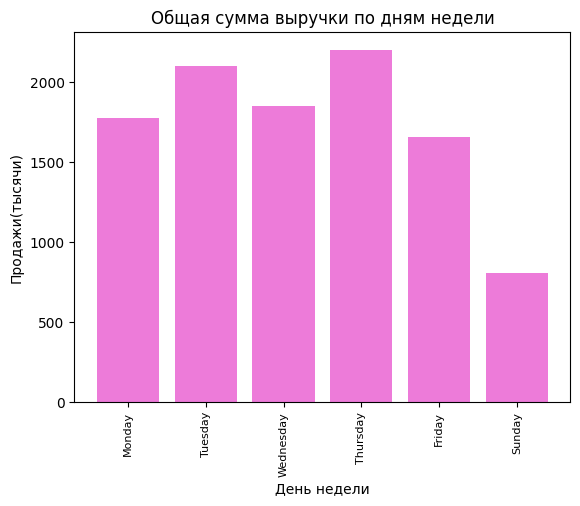

In [ ]:
plt.bar(DayTotal['Day'], DayTotal['Total']/1000, color='#ED7BD9')
plt.title('Общая сумма выручки по дням недели')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('Продажи(тысячи)')
plt.xlabel('День недели')
plt.show()

Посчитаем количество заказов по дням недели

In [ ]:
InvDay = data.groupby(['Day','InvoiceNo'])[['Total']].sum().reset_index()
InvDay

,Day,InvoiceNo,Total
0,Friday,536847,215.58
1,Friday,536848,534.00
2,Friday,536849,397.50
3,Friday,536851,1368.40
4,Friday,536852,89.14
...,...,...,...
19952,Wednesday,581193,144.15
19953,Wednesday,581194,312.22
19954,Wednesday,581195,12.48
19955,Wednesday,581196,331.30


In [ ]:
# суммарное количество заказов по дням недели
daySales = InvDay.groupby('Day')[['InvoiceNo']].count().sort_values('InvoiceNo', ascending=False).reset_index()
daySales

,Day,InvoiceNo
0,Thursday,4246
1,Wednesday,3690
2,Tuesday,3553
3,Friday,3138
4,Monday,3126
5,Sunday,2204


In [ ]:
# сделаем сортировку по дням недели
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daySales['Day'] = pd.Categorical(daySales['Day'], categories=cats, ordered=True)
daySales = daySales.sort_values('Day')
daySales

,Day,InvoiceNo
4,Monday,3126
2,Tuesday,3553
1,Wednesday,3690
0,Thursday,4246
3,Friday,3138
5,Sunday,2204


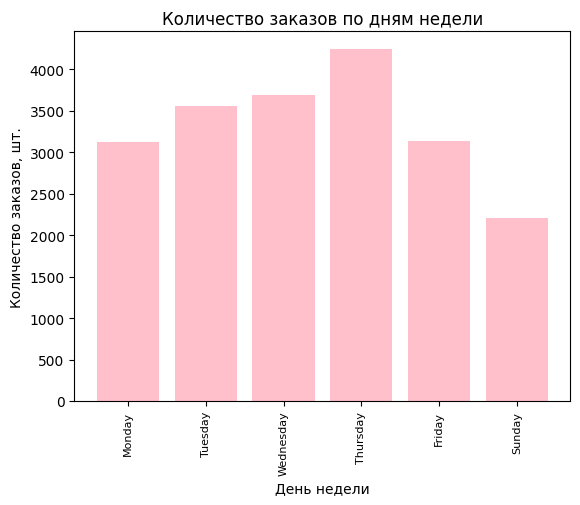

In [ ]:
plt.bar(daySales['Day'], daySales['InvoiceNo'], color='pink')
plt.title('Количество заказов по дням недели')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('Количество заказов, шт.')
plt.xlabel('День недели')
plt.show()

In [ ]:
# Средний чек по дням недели
AvgDay = InvDay.groupby('Day')[['Total']].mean().sort_values('Total', ascending=False).reset_index()


In [ ]:
# сделаем сортировку по дням недели
cats = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
AvgDay['Day'] = pd.Categorical(AvgDay['Day'], categories=cats, ordered=True)
AvgDay = AvgDay.sort_values('Day')
AvgDay

,Day,Total
1,Monday,568.068481
0,Tuesday,590.632398
4,Wednesday,500.562163
3,Thursday,517.968104
2,Friday,528.342521
5,Sunday,366.057523


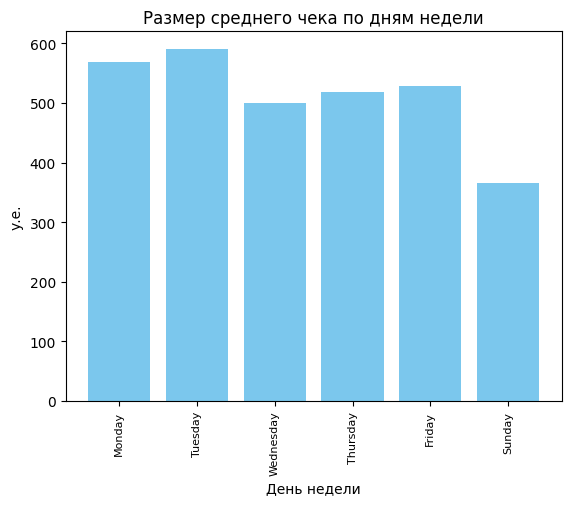

In [ ]:
plt.bar(AvgDay['Day'], AvgDay['Total'], color='#7BC7ED')
plt.title('Размер среднего чека по дням недели')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('у.е.')
plt.xlabel('День недели')
plt.show()

Вывод: Больше всего продаж совершается в четверг и вторник, а также в среду. Количество заказов также максимально в четверг. При этом размер среднего чека максимален во вторник и понедельник. Меньше всего было продано в воскресенье. Вероятно, начиная с пятницы люди готовятся к выходным и покупки предпочитают делать в середине рабочей недели.

4.3. Динамика продаж по часам. В какое время чаще всего совершаются покупки?

In [ ]:
data['Hour']=data['InvoiceDate'].dt.hour
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,15.30,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,22.00,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,12:50:00,Friday,2011-12,10.20,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12:50:00,Friday,2011-12,12.60,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60,12


In [ ]:
InvHour = data.groupby(['Hour','InvoiceNo'])[['Total']].sum().reset_index()
InvHour

,Hour,InvoiceNo,Total
0,6,563597,4.25
1,7,536598,160.60
2,7,536599,306.40
3,7,540688,234.00
4,7,542920,765.00
...,...,...,...
19953,20,573150,139.94
19954,20,573151,1062.18
19955,20,573152,218.83
19956,20,575731,169.69


In [ ]:
# суммарное количество заказов по часам
HourSales = InvHour.groupby('Hour')[['InvoiceNo']].count().sort_values('InvoiceNo', ascending=False).reset_index()
HourSales

,Hour,InvoiceNo
0,12,3220
1,13,2753
2,14,2456
3,11,2396
4,10,2360
5,15,2336
6,9,1483
7,16,1335
8,17,667
9,8,566


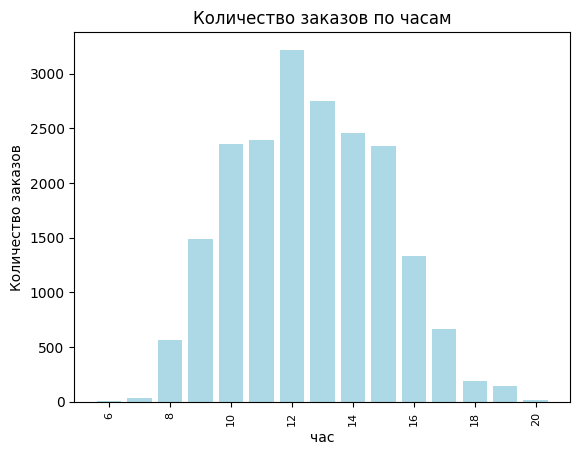

In [ ]:
plt.bar(HourSales['Hour'],HourSales['InvoiceNo'], color='lightblue')
plt.title('Количество заказов по часам')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('Количество заказов')
plt.xlabel('час')
plt.show()

In [ ]:
# размер среднего чека по часам
AvgHour = InvHour.groupby('Hour')[['Total']].mean().sort_values('Total', ascending=False).reset_index()
AvgHour

,Hour,Total
0,7,1071.007241
1,20,1046.248889
2,18,753.143802
3,17,691.100331
4,10,579.504733
5,15,578.053643
6,16,563.661393
7,9,554.002287
8,11,516.099036
9,8,501.326290


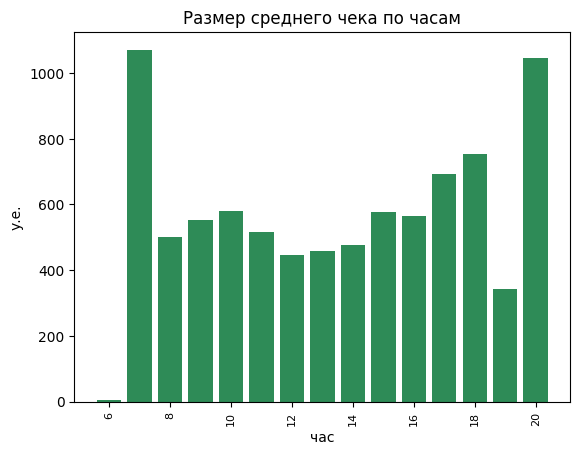

In [ ]:
plt.bar(AvgHour['Hour'], AvgHour['Total'], color='seagreen')
plt.title('Размер среднего чека по часам')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('у.е.')
plt.xlabel('час')
plt.show()

In [ ]:
# Суммарная выручка в течение дня
TotalHour = data.groupby(['Hour'])[['Total']].sum().sort_values('Total', ascending=False).reset_index()
TotalHour

,Hour,Total
0,12,1439324.660
1,10,1367631.171
2,15,1350333.310
3,13,1261195.200
4,11,1236573.290
5,14,1166845.461
6,9,821585.391
7,16,752487.960
8,17,460963.921
9,8,283750.680


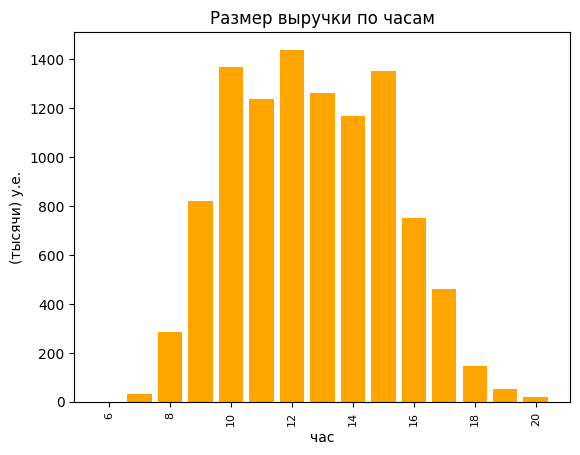

In [ ]:
plt.bar(TotalHour['Hour'], TotalHour['Total']/1000, color='orange')
plt.title('Размер выручки по часам')
plt.xticks(rotation = 'vertical',size = 8)
plt.ylabel('(тысячи) у.е.')
plt.xlabel('час')
plt.show()

Максимальные продажи наблюдаются в обеденное время, когда у людей рабочий перерыв. Следовательно лучше показывать рекламу именно в это время. При этом максимальный средний чек покупки в 7 утра и в 8 вечера. Возможно люди предпочитают совершать дорогие покупки, хорошо обдумав решение в течение дня, и делают сразу после пробуждения или вечером после рабочего дня. Или дело в разнице часовых поясов, покупатели с максимальным средним чеком не из Европы.

**5. Анализ количества покупателей в каждой стране. Среднее число заказов на человека**

In [ ]:
# очистим данные от нулевых покупателей, чтобы не искажали картину и неопределенных стран, чтобы посмотреть распределение покупателей по известным странам
filtered = data.loc[~((data['CustomerID'] == 0)|(data['Country'] == 'Unspecified'))] # убрать отфильтрованные строки
filtered

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Time,Day,Year_month,Total,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,15.30,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,22.00,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,08:26:00,Wednesday,2010-12,20.34,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,12:50:00,Friday,2011-12,10.20,12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12:50:00,Friday,2011-12,12.60,12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60,12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,12:50:00,Friday,2011-12,16.60,12


In [ ]:
filtered.groupby(['Country', 'CustomerID', 'InvoiceNo']).count().head(10)

StockCode  Description  Quantity  InvoiceDate  \
Country   CustomerID InvoiceNo                                                  
Australia 12386.0    537676             8            8         8            8   
                     540280             2            2         2            2   
          12388.0    541271            19           19        19           19   
                     543357             6            6         6            6   
                     546135            10           10        10           10   
                     560033            35           35        35           35   
                     568145            22           22        22           22   
                     578459             8            8         8            8   
          12393.0    540700            19           19        19           19   
                     541149             3            3         3            3   

                                UnitPrice  Time  Day  Year_month  Total  Hour  
Country   CustomerID InvoiceNo                                                 
Australia 12386.0    537676             8     8    8           8      8     8  
                     540280             2     2    2           2      2     2  
          12388.0    541271            19    19   19          19     19    19  
                     543357             6     6    6           6      6     6  
                     546135            10    10   10          10     10    10  
                     560033            35    35   35          35     35    35  
                     568145            22    22   22          22     22    22  
                     578459             8     8    8           8      8     8  
          12393.0    540700            19    19   19          19     19    19  
                     541149             3     3    3           3      3     3

In [ ]:
Customers = filtered.groupby(['Country', 'CustomerID', 'InvoiceNo']).count().reset_index()
Customers.head()

,Country,CustomerID,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,Time,Day,Year_month,Total,Hour
0,Australia,12386.0,537676,8,8,8,8,8,8,8,8,8,8
1,Australia,12386.0,540280,2,2,2,2,2,2,2,2,2,2
2,Australia,12388.0,541271,19,19,19,19,19,19,19,19,19,19
3,Australia,12388.0,543357,6,6,6,6,6,6,6,6,6,6
4,Australia,12388.0,546135,10,10,10,10,10,10,10,10,10,10


In [ ]:
Number_of_orders_perPerson = Customers.groupby(['Country', 'CustomerID'])[['InvoiceNo']].count().reset_index() # кол-во заказов на человека
Number_of_orders_perPerson

,Country,CustomerID,InvoiceNo
0,Australia,12386.0,2
1,Australia,12388.0,6
2,Australia,12393.0,4
3,Australia,12415.0,21
4,Australia,12422.0,2
...,...,...,...
4336,United Kingdom,18280.0,1
4337,United Kingdom,18281.0,1
4338,United Kingdom,18282.0,2
4339,United Kingdom,18283.0,16


In [ ]:
Number_of_orders_perPerson['InvoiceNo'].mean() # среднее количество заказов на человека в целом

4.266758811333794

In [ ]:
# среднее количество заказов на человека по каждой стране
Number_of_orders_perPerson.groupby('Country')[['InvoiceNo']].mean().sort_values('InvoiceNo', ascending = False).reset_index().head(10)

,Country,InvoiceNo
0,EIRE,86.666667
1,Netherlands,10.444444
2,Singapore,7.000000
3,Iceland,7.000000
4,Australia,6.333333
5,Germany,4.861702
6,Sweden,4.500000
7,France,4.471264
8,United Kingdom,4.247002
9,Lithuania,4.000000


В Ирландии самое высокое количество заказов на человека. Очевидно, там проживают наши самые лояльные покупатели, скорее всего оптовики. В остальных странах количество заказов на человека значительно меньше.

In [ ]:
# количество уникальных покупателей в каждой стране.
CustomersNo = Number_of_orders_perPerson.groupby('Country')[['CustomerID']].count().sort_values('CustomerID', ascending = False).reset_index()
CustomersNo.head(10)

,Country,CustomerID
0,United Kingdom,3919
1,Germany,94
2,France,87
3,Spain,30
4,Belgium,25
5,Switzerland,21
6,Portugal,19
7,Italy,14
8,Finland,12
9,Austria,11


In [ ]:
# общее количество уникальных покупателей
CustomersNo['CustomerID'].sum()

4341

Выводы: Общее количество покупателей 4341. Основные покупатели, конечно же из Великобритании, покупателей из других стран существенно меньше. Из таблицы видно, что в Ирладнии проживает всего три покупателя, при этом количество покупок и общая выручка от этих покупателей входит в топ-10  стран по общей выручке. Возможно им стоит предложить специальные условия.


**
                            **Выводы:**

Дела у магазина ТАТА судя по данным идут хорошо. Сумма возвратов составляет не более 8,5% от общей выручки. Основная масса клиентов идет из Великобритании. Из других стран количество клиентов существенно меньше. При этом покупатели не из Европы предпочитают совершать покупки на крупный чек, очевидно делая оптовые заказы. Больше всего покупок совершается в обеденное время и в будние дни в середине недели. Динамика продаж магазина в целом положительная, идет на увеличение. Наблюдается постепенный рост продаж к концу года, особенно в ноябре.

**Рекомендации:**

В ходе анализа было выявлено отсутствие некоторых данных, необходимых для предоставления четких выводов, поэтому для улучшения качества данных необходимо доработать отчет и дополнить данные следующей информацией:
Данные о продажах магазина по субботам, данные о продажах за декабрь 2011 года.
•	Добавить информацию о типе каждого товара, например, одежда, сумки, украшения и т.д. для более детального анализа данных.
•	Расставить приоритеты в маркетинге по четвергам, этого можно было бы добиться, рекламируя больше предложений по четвергам.
•	Размещать рекламу в обеденное время с 12-14 дня.
•	Уделить приоритетное внимание маркетингу в Великобритании как стране с наибольшим количеством клиентов и сделок.
•	Сосредоточить маркетинг на самых продаваемых продуктах Топ-10.
•	Ориентироваться на тех покупателей, которые не тратят много денег, продавая больше товаров по цене от 1,9 до 2,7 долларов.
•	Для покупателей из стран не из Европы сделать более гибкие условия доставки для оптовых закупок. Предлагать больше товаров по оптовым ценам.

**